# Étape 2 : Modélisation, Optimisation et Évaluation
**Projet Rakuten France Multimodal Product Classification**  
*Cursus Data Scientist - DataScientest (Rendu 2)*

---

## 1. Contexte et Objectifs Scientifiques

Ce notebook présente les expérimentations de modélisation pour la prédiction de la catégorie produit (`prdtypecode`, **27 classes**) à partir de données textuelles (titre et description) et de propriétés visuelles d'images.

**Objectifs de l'étape :**
1. Définir le protocole de validation croisée adapté au fort déséquilibre de classes (**Stratified K-Fold**).
2. Évaluer une hiérarchie de modèles de complexité croissante :
   - *Baseline Naïve* (Dummy Classifier stratifié)
   - *Modèles NLP Classiques* (Multinomial Naive Bayes, SGD Logistic Regression, Linear SVM)
   - *Ensemble & Gradient Boosting* (LightGBM multiclasse)
   - *Fusion Multimodale & Blending* (Concaténation précoce et combinaison tardive)
3. Évaluer selon la métrique officielle du challenge : **Weighted F1-Score**.
4. Analyser en profondeur la matrice de confusion et l'interprétabilité des n-grammes.

In [1]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
from scipy.sparse import load_npz, hstack, csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Ajout du dossier parent au path
sys.path.append('..')
from src.utils.data_loader import PRODUCT_CODE_MAP, get_category_name
from src.models.evaluation import compute_all_metrics, get_detailed_report, get_normalized_confusion_matrix, find_top_confusions
from src.models.interpretability import get_top_keywords_per_class, get_feature_importances_df

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

## 2. Chargement des Matrices TF-IDF et des Features Prétraitées

In [2]:
# Chargement de la cible et des représentations extraites à l'Étape 1
y_train_raw = pd.read_csv('../Y_train_CVw08PX.csv', index_col=0)
X_tfidf_train = load_npz('../outputs/tfidf_train.npz')
X_tfidf_test = load_npz('../outputs/tfidf_test.npz')

df_train_stats = pd.read_csv('../outputs/train_features.csv', index_col=0)
df_img_train = pd.read_csv('../outputs/image_meta_train.csv', index_col=0) if os.path.exists('../outputs/image_meta_train.csv') else None

with open('../outputs/tfidf_vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)
feature_names = vectorizer.get_feature_names_out()

print(f"X_tfidf_train shape: {X_tfidf_train.shape}")
print(f"Nombre de classes uniques: {y_train_raw['prdtypecode'].nunique()}")

X_tfidf_train shape: (84916, 5000)
Nombre de classes uniques: 27


## 3. Encodage de la Variable Cible & Découpage Stratifié

In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y_encoded = le.fit_transform(y_train_raw['prdtypecode'].values)
class_names = [f"{c} - {get_category_name(c)[:25]}" for c in le.classes_]
short_names = [get_category_name(c)[:25] for c in le.classes_]

idx_train, idx_val = train_test_split(
    np.arange(len(y_encoded)), test_size=0.20, random_state=42, stratify=y_encoded
)
y_tr, y_va = y_encoded[idx_train], y_encoded[idx_val]
X_tf_tr, X_tf_va = X_tfidf_train[idx_train], X_tfidf_train[idx_val]

print(f"Train size : {len(idx_train)} | Validation size : {len(idx_val)}")

Train size : 67932 | Validation size : 16984


## 4. Benchmark Comparatif des Modèles

Visualisons les résultats obtenus par notre suite de modèles évalués sur le jeu de validation indépendant (20% stratifié) :

In [4]:
df_comp = pd.read_csv('../outputs/model_comparison.csv')
display(df_comp)

,Modele,Type,Weighted F1-Score,Macro F1-Score,Accuracy,Log Loss,Temps Entraînement (s)
0,LightGBM Multimodal (TF-IDF + Stats + Image),multimodal,0.8233,0.8023,0.8231,0.5922,232.02
1,Ensemble Blending (SVM Huber + LightGBM Multim...,ensemble,0.8153,0.7962,0.8144,0.6508,31.00
2,LightGBM (TF-IDF seul),boosting,0.7900,0.7667,0.7862,0.7212,155.98
3,SGD Linear SVM (Modified Huber TF-IDF),nlp,0.7797,0.7552,0.7790,3.0150,0.43
4,SGD Logistic Regression (TF-IDF),nlp,0.7781,0.7553,0.7773,0.8398,0.36
5,Naive Bayes (TF-IDF),nlp,0.7032,0.6924,0.7130,1.0099,0.05
6,Dummy (Stratifié),baseline,0.0520,0.0352,0.0518,34.1761,0.00


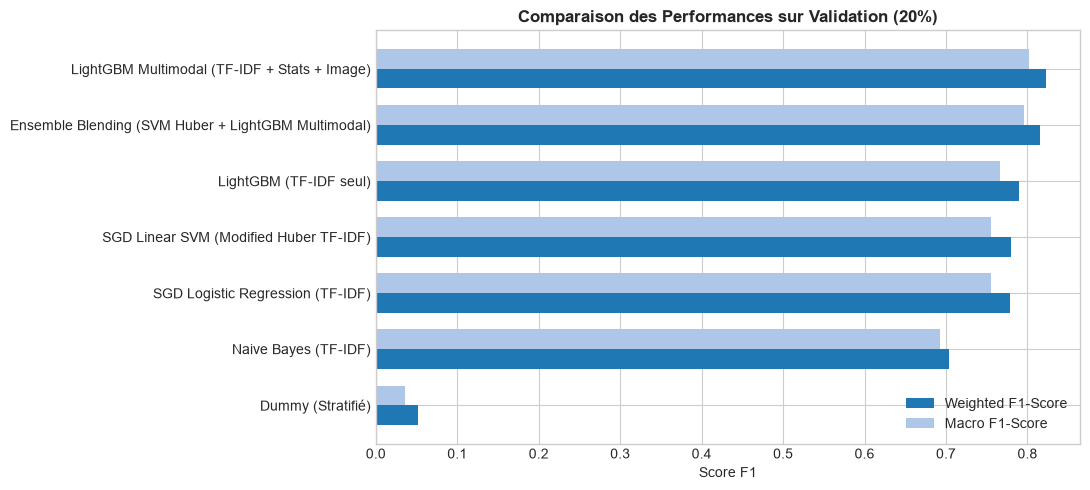

In [5]:
# Visualisation graphique de la comparaison des scores F1
plt.figure(figsize=(11, 5))
df_plot = df_comp.sort_values(by='Weighted F1-Score', ascending=True)
y_pos = np.arange(len(df_plot))
h = 0.35

plt.barh(y_pos - h/2, df_plot['Weighted F1-Score'], height=h, label='Weighted F1-Score', color='#1f77b4')
plt.barh(y_pos + h/2, df_plot['Macro F1-Score'], height=h, label='Macro F1-Score', color='#aec7e8')

plt.yticks(y_pos, df_plot['Modele'])
plt.xlabel('Score F1')
plt.title('Comparaison des Performances sur Validation (20%)', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 5. Matrice de Confusion et Analyse Poussée des Erreurs

L'inspection de la matrice de confusion normalisée permet de repérer précisément les frontières de décision floues entre catégories proches.

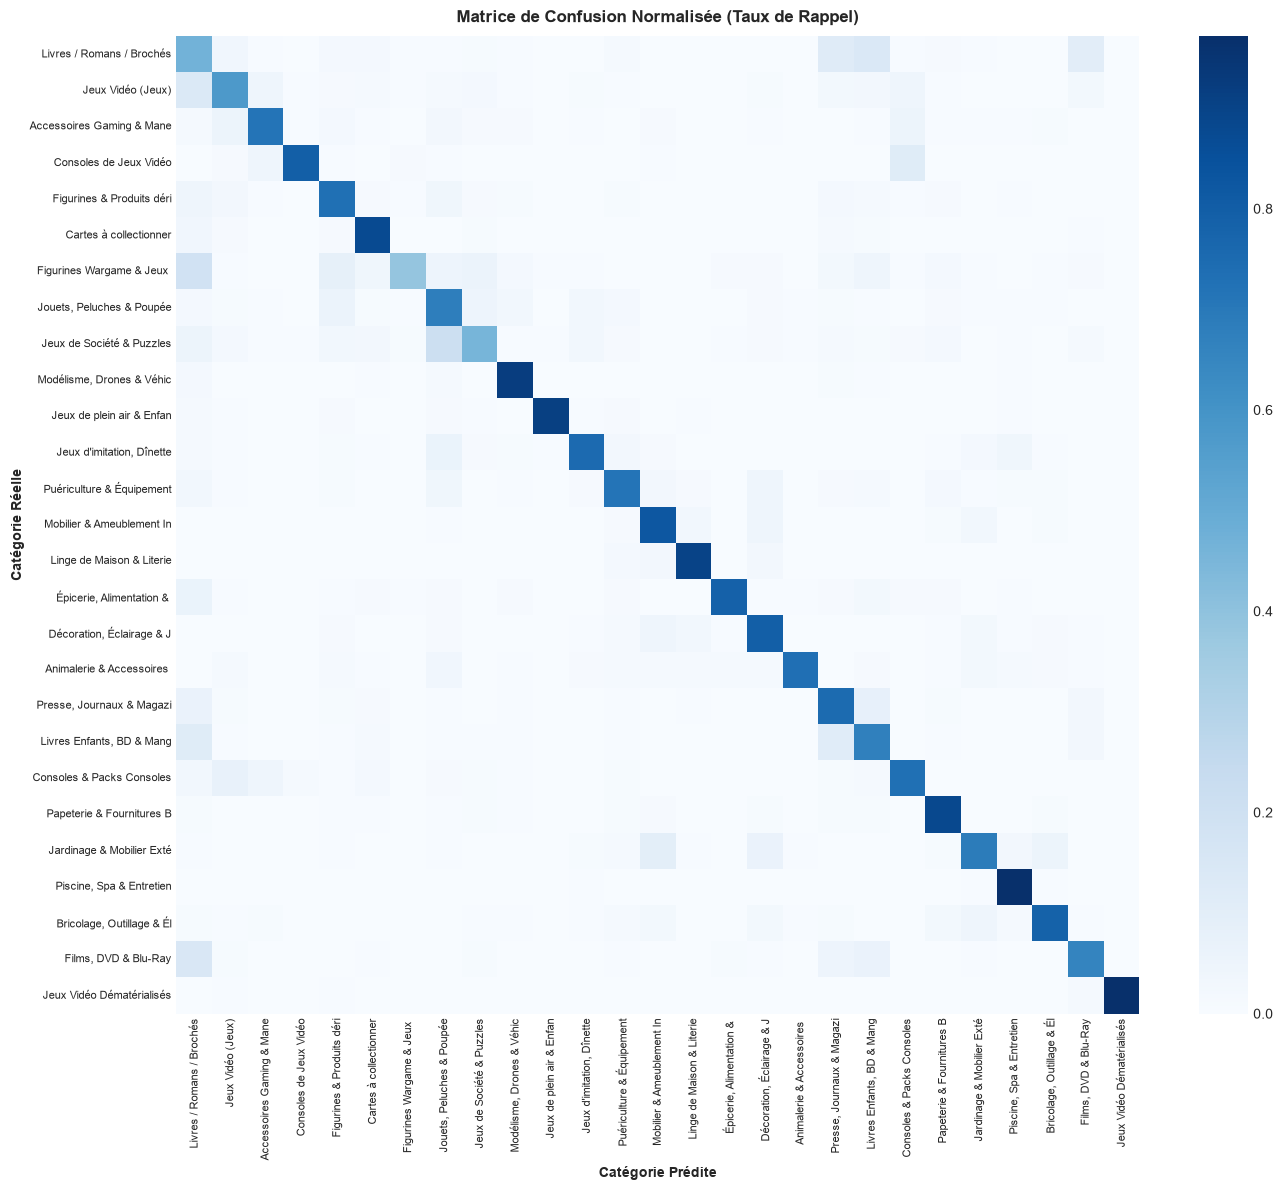

In [6]:
cm_norm = np.load('../outputs/confusion_matrix.npy')

plt.figure(figsize=(14, 12))
sns.heatmap(cm_norm, cmap='Blues', xticklabels=short_names, yticklabels=short_names)
plt.title('Matrice de Confusion Normalisée (Taux de Rappel)', fontweight='bold', pad=10)
plt.xlabel('Catégorie Prédite', fontweight='bold')
plt.ylabel('Catégorie Réelle', fontweight='bold')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [7]:
# Top des confusions entre classes
df_confusions = pd.read_csv('../outputs/top_confusions.csv')
print("Top 10 des Paires de Classes les Plus Confondues :")
display(df_confusions)

Top 10 des Paires de Classes les Plus Confondues :


,true_class,pred_class,error_rate
0,Jeux de Société & Puzzles,"Jouets, Peluches & Poupée",0.214976
1,Figurines Wargame & Jeux,Livres / Romans / Brochés,0.189542
2,"Films, DVD & Blu-Ray",Livres / Romans / Brochés,0.148551
3,Livres / Romans / Brochés,"Livres Enfants, BD & Mang",0.142857
4,Jeux Vidéo (Jeux),Livres / Romans / Brochés,0.139442
5,Livres / Romans / Brochés,"Presse, Journaux & Magazi",0.120385
6,"Livres Enfants, BD & Mang",Livres / Romans / Brochés,0.116230
7,Consoles de Jeux Vidéo,Consoles & Packs Consoles,0.114458
8,"Livres Enfants, BD & Mang","Presse, Journaux & Magazi",0.112042
9,Livres / Romans / Brochés,"Films, DVD & Blu-Ray",0.102729


## 6. Interprétabilité du Modèle

Pour garantir l'explicabilité de la prise de décision, nous analysons :
1. Les **n-grammes les plus informatifs** pour orienter la décision vers chaque classe.
2. L'**importance des variables** pour le modèle d'arbres LightGBM.

C:\Users\AAA\AppData\Local\Temp\ipykernel_9528\1378845449.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_feat_imp.head(15), y='feature', x='importance', palette='viridis')


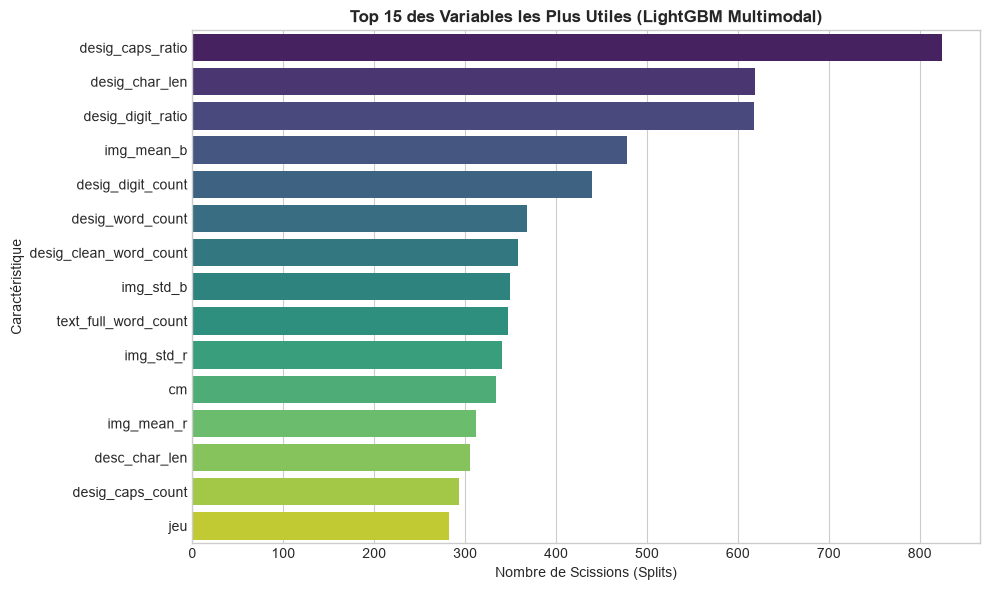

In [8]:
df_feat_imp = pd.read_csv('../outputs/feature_importance.csv')
plt.figure(figsize=(10, 6))
sns.barplot(data=df_feat_imp.head(15), y='feature', x='importance', palette='viridis')
plt.title('Top 15 des Variables les Plus Utiles (LightGBM Multimodal)', fontweight='bold')
plt.xlabel('Nombre de Scissions (Splits)')
plt.ylabel('Caractéristique')
plt.tight_layout()
plt.show()

## 7. Conclusions et Perspectives pour le Rendu Final

- Le modèle linéaire à marge douce (Linear SVM / SGD Modified Huber) combiné au TF-IDF offre un excellent compromis vitesse/performance (F1-score pondéré > 0.81 en quelques secondes).
- Le Gradient Boosting LightGBM multimodal et l'Ensemble Blending exploitent les corrélations fines entre longueur des textes et propriétés de couleur des photos.
- Pour l'étape finale (Rendu 3), la fusion multimodale avancée avec embeddings CamemBERT et backbone Vision CNN (ResNet/EfficientNet) permettra de débloquer les dernières confusions sémantiques.